# CT VAE implementation from scratch

## Setup

In [1]:
import copy
import gc
import glob
import math
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import nibabel as nib
import torch
import torch.nn as nn
from monai.apps.generation.maisi.networks.autoencoderkl_maisi import AutoencoderKlMaisi
from monai.data import CacheDataset, Dataset, ThreadDataLoader
from monai.losses import SSIMLoss
from monai.networks.utils import normal_init
from monai.transforms import (
    Compose,
    CopyItemsd,
    DeleteItemsd,
    DivisiblePadd,
    EnsureChannelFirstd,
    EnsureTyped,
    LoadImaged,
    MapTransform,
    Orientationd,
    RandCropByPosNegLabeld,
    ScaleIntensityRanged,
    ThresholdIntensityd,
)
from torch.amp import autocast
from torch.optim.lr_scheduler import OneCycleLR
from tqdm import tqdm

In [2]:
# Find project root (folder that contains .git)
ROOT = Path.cwd()
while not (ROOT / ".git").exists():
    ROOT = ROOT.parent

# Set working directory to root
os.chdir(ROOT)

print("Now working in:", Path.cwd())

Now working in: C:\Users\couch\Documents\robust-radiotherapy-planning


In [3]:
from src.data_utils import create_data_split_dict

In [4]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")

PyTorch version: 2.11.0+cu128
CUDA available: True
CUDA version: 12.8


In [5]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE_STR = str(DEVICE)
print(f"Using device: {DEVICE_STR}")

Using device: cuda


In [6]:
# Optimizations taking advantage of Blackwell and fixed input size
torch.set_float32_matmul_precision("high")
torch.backends.cudnn.benchmark = True

In [7]:
# Context manager for timing execution
class Timer:
    def __init__(self, task_name):
        self.task_name = task_name

    def __enter__(self):
        self.start = time.perf_counter()
        return self

    def __exit__(self, *args):
        self.end = time.perf_counter()
        seconds = int(self.end - self.start)

        hours = seconds // 3600
        minutes = (seconds % 3600) // 60
        secs = seconds % 60

        print(f"{self.task_name} time: {hours:02}:{minutes:02}:{secs:02}")

In [8]:
# DATA LOCATION CONFIG
TEST_DIR = "notebooks/data/transformed_ct/test"
TRAIN_DIR = "notebooks/data/transformed_ct/train"
VAL_DIR = "notebooks/data/transformed_ct/val"

# DATA PREPROCESSING CONFIG
POS_THRESHOLD = 0.25
TARGET_SIZE = (96, 96, 64)

# MODEL CONFIG
INIT_STD = 0.01
KLD_WEIGHT = 0.01
LATENT_CHANNELS = 4
NUM_CHANNELS_START = 64
NUM_LAYERS = 3
NUM_NORM_GROUPS = 32
NUM_RES_BLOCKS = 2
RECON_WEIGHT = 2
SIGMOID_EXPANSION = 1.02
SOB_WEIGHT = 0.01
SSIM_WEIGHT = 0.05
VAR_WEIGHT = 0.01

# TRAINING CONFIG
ACCUMULATION_STEPS = 64
BATCH_SIZE = 1
CHECKPOINT_FOLDER = "notebooks/models/checkpoints"
EMA_DECAY = 0.99
EVAL_BATCH_SIZE = 8
EPOCHS = 500
LR_END = 1e-7
LR_MAX = 1e-5
LR_START = 1e-6
LR_WARMUP = 0.2
MAX_GRADIENT_NORM = 5
PATIENCE = float("inf")
WEIGHT_DECAY = 1e-2

## Data loading

In [9]:
# Load data dictionaries
data_dict = create_data_split_dict(
    seed=42,
    train_fraction=0.8,
    folds=5,
    save=False,
)

In [10]:
transform = Compose(
    [
        LoadImaged(keys="image"),
        EnsureChannelFirstd(keys="image"),
        Orientationd(keys="image", axcodes="RAS", labels=None),
        # Move from -1000:1000 to 0:1 for numerical stability
        ScaleIntensityRanged(keys="image", a_min=-1000, a_max=1000, b_min=0, b_max=1, clip=True),
        # Pad the image so depth is a multiple of 32 (so VAE encoding and decoding is simple)
        DivisiblePadd(keys="image", k=32),
        EnsureTyped(keys="image", dtype=torch.float16),
    ]
)

# Use a random crop for validation
validation_transform = Compose(
    [
        LoadImaged(keys="image"),
        EnsureChannelFirstd(keys="image"),
        Orientationd(keys="image", axcodes="RAS", labels=None),
        # Move from -1000:1000 to 0:1 for numerical stability
        ScaleIntensityRanged(keys="image", a_min=-1000, a_max=1000, b_min=0, b_max=1, clip=True),
        # Pad the image so depth is a multiple of 32 (so VAE encoding and decoding is simple)
        DivisiblePadd(keys="image", k=32),
        # Take a random crop, centered at a foreground pixel (reaches the POS_THRESHOLD)
        CopyItemsd(keys=["image"], times=1, names=["mask"]),
        ThresholdIntensityd(keys=["mask"], threshold=POS_THRESHOLD, above=True, cval=0),
        RandCropByPosNegLabeld(
            keys=["image", "mask"],
            label_key="mask",
            spatial_size=TARGET_SIZE,
            pos=1,
            neg=0,
            num_samples=1,
        ),
        DeleteItemsd(keys=["mask"]),
        EnsureTyped(keys="image", dtype=torch.float16),
    ]
)

Original shape: (512, 512, 126)
Original affine: [[1.171875 0.       0.       0.      ]
 [0.       1.171875 0.       0.      ]
 [0.       0.       3.       0.      ]
 [0.       0.       0.       1.      ]]


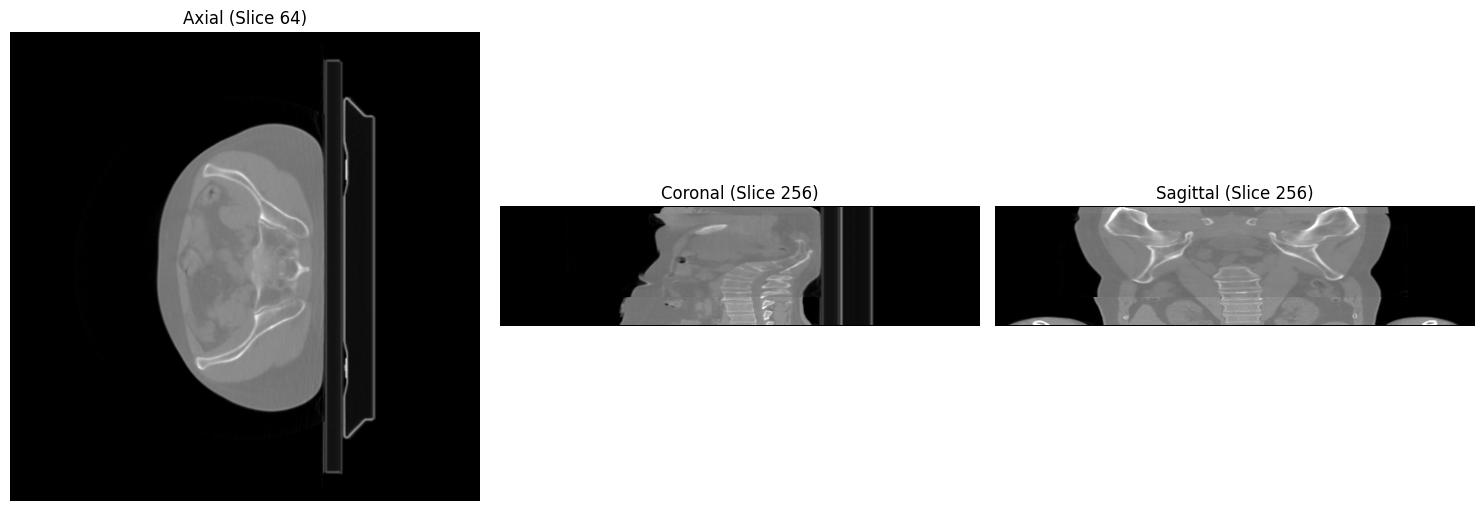

Tensor min/max: 0.0000, 1.0000


In [11]:
# Process an example image
img_path = data_dict[0]["train"][0]
img_nib = nib.load(img_path)
original_shape = img_nib.shape
original_affine = img_nib.affine
print(f"Original shape: {original_shape}")
print(f"Original affine: {original_affine}")

image_dict = {"image": img_path}
transformed_dict = transform(image_dict)
img_tensor = transformed_dict["image"]

# Matplotlib handles 32-bit float better
img_array = img_tensor.detach().cpu().float().numpy()

# Squeeze the channel dimension (C, H, W, D) -> (H, W, D)
img_array = img_array[0]

# Get middle indices for each axis
idx_h, idx_w, idx_d = [s // 2 for s in img_array.shape]

# Create the plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Axial view (Top-down)
axes[0].imshow(img_array[:, :, idx_d].T, cmap="gray", origin="lower")
axes[0].set_title(f"Axial (Slice {idx_d})")
axes[0].axis("off")

# Coronal view (Front-to-back)
axes[1].imshow(img_array[:, idx_w, :].T, cmap="gray", origin="lower")
axes[1].set_title(f"Coronal (Slice {idx_w})")
axes[1].axis("off")

# Sagittal view (Side-to-side)
axes[2].imshow(img_array[idx_h, :, :].T, cmap="gray", origin="lower")
axes[2].set_title(f"Sagittal (Slice {idx_h})")
axes[2].axis("off")

plt.tight_layout()
plt.show()

# Quick check on values
print(f"Tensor min/max: {img_tensor.min():.4f}, {img_tensor.max():.4f}")

In [12]:
def process_and_save_cts(output_dir, data_path_list, validation=False):
    os.makedirs(output_dir, exist_ok=True)

    for path in tqdm(data_path_list):
        # Run the transform
        image_dict = {"image": path}
        if validation:
            transformed_dict = validation_transform(image_dict)[0]
        else:
            transformed_dict = transform(image_dict)

        tensor_data = transformed_dict["image"]

        # Generate a clean filename
        original_name = os.path.basename(path).replace(".nii.gz", ".pt")
        save_path = os.path.join(output_dir, original_name)

        # Save as a torch tensor
        clean_tensor = tensor_data.as_tensor().clone().detach()
        torch.save(clean_tensor, save_path)

In [13]:
# print("Processing train data...")
# process_and_save_cts(TRAIN_DIR, data_dict[0]["train"])
# print("Processing validation data...")
# process_and_save_cts(VAL_DIR, data_dict[0]["val"], validation=True)
# print("Processing test data...")
# process_and_save_cts(TEST_DIR, data_dict["test"])

In [14]:
# Class for loading processed .pt files
class LoadProcessedTensord(MapTransform):
    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            # Load the .pt file directly into memory
            # weights_only=True helps with security/speed
            d[key] = torch.load(d[key], weights_only=True)
        return d

In [15]:
# Transform to be used for training
train_transform = Compose(
    [
        LoadProcessedTensord(keys=["image"]),
        # Take a random crop, centered at a foreground pixel (reaches the POS_THRESHOLD)
        CopyItemsd(keys=["image"], times=1, names=["mask"]),
        ThresholdIntensityd(keys=["mask"], threshold=POS_THRESHOLD, above=True, cval=0),
        RandCropByPosNegLabeld(
            keys=["image", "mask"],
            label_key="mask",
            spatial_size=TARGET_SIZE,
            pos=1,
            neg=0,
            num_samples=1,
        ),
        DeleteItemsd(keys=["mask"]),
        EnsureTyped(keys=["image"], track_meta=False),
    ]
)

# Transform to be used for evaluation
standard_transform = Compose(
    [
        LoadProcessedTensord(keys=["image"]),
        EnsureTyped(keys=["image"], track_meta=False),
    ]
)

# Create Datasets
train_files = [{"image": f} for f in sorted(glob.glob(os.path.join(TRAIN_DIR, "*.pt")))]
val_files = [{"image": f} for f in sorted(glob.glob(os.path.join(VAL_DIR, "*.pt")))]
test_files = [{"image": f} for f in sorted(glob.glob(os.path.join(TEST_DIR, "*.pt")))]

train_ds = Dataset(data=train_files, transform=train_transform)
val_ds = CacheDataset(data=val_files, transform=standard_transform)
test_ds = Dataset(data=test_files, transform=standard_transform)

# Create DataLoaders
train_loader = ThreadDataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, pin_memory=True)
val_loader = ThreadDataLoader(val_ds, batch_size=EVAL_BATCH_SIZE, shuffle=False, pin_memory=True)
test_loader = ThreadDataLoader(test_ds, batch_size=EVAL_BATCH_SIZE, shuffle=False, pin_memory=True)

Loading dataset: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 282/282 [00:00<00:00, 476.60it/s]


## VAE training

In [16]:
# Not actually equivalent to log(cosh(x)), but is a very good approximation for small x
# and converges to L1 loss for large x
def log_cosh_loss(prediction, target):
    error = torch.abs(prediction - target)
    return torch.mean(error + torch.nn.functional.softplus(-2.0 * error) - torch.log(torch.tensor(2.0)))

In [17]:
def get_sobel_kernels(device):
    # 1D components
    h = torch.tensor([1, 2, 1], dtype=torch.float32, device=device)
    d = torch.tensor([-1, 0, 1], dtype=torch.float32, device=device)

    # Construct 3D kernels using outer products
    # Sobel X: derivative in X, smooth in Y and Z
    kernel_x = d.view(3, 1, 1) * h.view(1, 3, 1) * h.view(1, 1, 3)
    # Sobel Y: derivative in Y, smooth in X and Z
    kernel_y = h.view(3, 1, 1) * d.view(1, 3, 1) * h.view(1, 1, 3)
    # Sobel Z: derivative in Z, smooth in X and Y
    kernel_z = h.view(3, 1, 1) * h.view(1, 3, 1) * d.view(1, 1, 3)

    # Stack them: shape [3, 1, 3, 3, 3] (3 out_channels, 1 in_channel, 3x3x3)
    kernels = torch.stack([kernel_x, kernel_y, kernel_z]).unsqueeze(1)
    return kernels

In [18]:
def total_variation_loss(img):
    # Differences between neighboring voxels along each axis
    tv_d = torch.abs(img[:, :, 1:, :, :] - img[:, :, :-1, :, :])
    tv_h = torch.abs(img[:, :, :, 1:, :] - img[:, :, :, :-1, :])
    tv_w = torch.abs(img[:, :, :, :, 1:] - img[:, :, :, :, :-1])

    return (tv_d.mean() + tv_h.mean() + tv_w.mean()) / 3.0

In [19]:
class AutoencoderModel(AutoencoderKlMaisi):
    def __init__(self, sigmoid_expansion, *args, **kwargs):
        super().__init__(*args, **kwargs)

        self.ssim_loss_func = SSIMLoss(spatial_dims=3)
        self.sobel_kernels = get_sobel_kernels(DEVICE)

        self.sigmoid_expansion = sigmoid_expansion

    # Override the decode method to use expanded sigmoid on the output logits
    def decode(self, z):
        logits = self.decoder(z)

        centering_correction = (self.sigmoid_expansion - 1) / 2

        recon_x = self.sigmoid_expansion * torch.sigmoid(logits) - centering_correction

        return recon_x

    def loss_function(self, x, recon_x, mu, logvar, recon_weight, ssim_weight, sob_weight, var_weight, kld_weight):
        # Immediately upcast to float32 for numerical stability
        x = x.float()
        recon_x = recon_x.float()
        mu = mu.float()
        logvar = logvar.float()
        self.sobel_kernels = self.sobel_kernels.float()

        # Calculate a clamped version of the reconstruction to use in most losses
        # The log-cosh still uses the unclamped version to punish the model for deviating from the data range
        recon_x_clampled = torch.clamp(recon_x, 0, 1)

        # Calculate log-cosh loss (punishes wrong voxel values)
        RECON = log_cosh_loss(recon_x, x)

        # Calculate SSIM loss (punishes mismatched area texture)
        SSIM = self.ssim_loss_func(recon_x_clampled, x)

        # Calculate Sobel loss (punishes bad edges within the image)
        real_grads = nn.functional.conv3d(x, self.sobel_kernels, padding=1)
        recon_grads = nn.functional.conv3d(recon_x_clampled, self.sobel_kernels, padding=1)
        SOB = nn.functional.l1_loss(recon_grads, real_grads)

        # Calculate total variation loss (punishes noisy output)
        VAR = total_variation_loss(recon_x_clampled)

        # Clamp to prevent exponential overflow in bfloat16
        # -10 to 10 keeps exp(logvar) well within the ~65k limit
        mu = torch.clamp(mu, min=-10, max=10)
        logvar = torch.clamp(logvar, min=-10, max=10)

        # KLD is normalized by the number of voxels in the image instead of through a regular mean
        KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.numel()

        # Calculate the aggregate loss function
        loss = recon_weight * RECON + ssim_weight * SSIM + sob_weight * SOB + var_weight * VAR + kld_weight * KLD

        return loss, RECON, SSIM, SOB, VAR, KLD

    def calculate_batch_loss(self, x, recon_weight, ssim_weight, sob_weight, var_weight, kld_weight):
        return self.loss_function(x, *self(x), recon_weight, ssim_weight, sob_weight, var_weight, kld_weight)

In [20]:
class EMA:
    def __init__(self, model, decay):
        # Create a deep copy of the model to store the moving average
        self.backup = copy.deepcopy(model.state_dict())
        self.ema_model = copy.deepcopy(model)
        self.ema_model.eval()
        self.decay = decay

        # Ensure EMA weights don't track gradients
        for param in self.ema_model.parameters():
            param.requires_grad = False

    @torch.no_grad()
    def update(self, model):
        # Move through the weights and update the EMA version
        for ema_param, model_param in zip(self.ema_model.parameters(), model.parameters(), strict=True):
            ema_param.data.mul_(self.decay).add_(model_param.data, alpha=1 - self.decay)

    def apply_shadow(self, model):
        self.backup = copy.deepcopy(model.state_dict())
        model.load_state_dict(self.ema_model.state_dict())

    def restore(self, model):
        model.load_state_dict(self.backup)

In [21]:
def save_checkpoint(state, file):
    torch.save(state, file)


def load_checkpoint(file, model, optimizer, scheduler, ema):
    checkpoint = torch.load(file, map_location=DEVICE_STR)

    model.load_state_dict(checkpoint["state_dict"])
    ema.ema_model.load_state_dict(checkpoint["ema_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_dict"])
    scheduler.load_state_dict(checkpoint["scheduler_dict"])

    return (
        checkpoint["epoch"],
        checkpoint["epochs_no_improve"],
        checkpoint["best_loss"],
        checkpoint["best_model_dict"],
        checkpoint["history"],
        checkpoint["step"],
    )

In [22]:
def train(
    model,
    optimizer,
    train_loader,
    val_loader,
    lr_start=LR_START,
    lr_max=LR_MAX,
    lr_end=LR_END,
    lr_warmup=LR_WARMUP,
    recon_weight=RECON_WEIGHT,
    ssim_weight=SSIM_WEIGHT,
    sob_weight=SOB_WEIGHT,
    var_weight=VAR_WEIGHT,
    kld_weight=KLD_WEIGHT,
    ema_decay=EMA_DECAY,
    accumulation_steps=ACCUMULATION_STEPS,
    max_gradient_norm=MAX_GRADIENT_NORM,
    epochs=EPOCHS,
    patience=PATIENCE,
    checkpoint_folder=CHECKPOINT_FOLDER,
    logging=False,
):
    # Ensure the checkpoint directory exists
    os.makedirs(checkpoint_folder, exist_ok=True)

    # Initialize EMA
    ema = EMA(model, decay=ema_decay)

    # Define number of steps for scheduling
    total_steps = math.floor(epochs * len(train_loader) / accumulation_steps)

    # Define learning rate scheduler
    scheduler = OneCycleLR(
        optimizer,
        max_lr=lr_max,
        total_steps=total_steps,
        pct_start=lr_warmup,
        anneal_strategy="cos",
        div_factor=lr_max / lr_start,
        final_div_factor=lr_max / lr_end,
    )

    # Initialize checkpoint location
    checkpoint_file = f"{checkpoint_folder}/checkpoint.pth.tar"

    # Load checkpoint if it is available
    if os.path.isfile(checkpoint_file):
        if logging:
            print("Loading checkpoint...")
        start_epoch, epochs_no_improve, best_val_loss, best_model_wts, history, step = load_checkpoint(
            checkpoint_file, model, optimizer, scheduler, ema
        )
        start_epoch += 1

        avg_val_loss = history["val"][-1]
    # Define starting values if there is no checkpoint
    else:
        if logging:
            print("Starting from scratch...")

        start_epoch, epochs_no_improve, best_val_loss, best_model_wts, step = (
            0,
            0,
            float("inf"),
            copy.deepcopy(model.state_dict()),
            0,
        )

        history = {
            "train": [],
            "val": [],
        }

        avg_val_loss = float("inf")

    for epoch in range(start_epoch, epochs):
        # EARLY STOPPING LOGIC
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            # Save the best version of the model
            best_model_wts = copy.deepcopy(model.state_dict())
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping triggered at epoch {epoch}. Restoring best weights...")
                break

        # TRAINING PHASE
        ema.restore(model)
        model.train()

        train_loss = torch.tensor(0.0, device=DEVICE_STR, dtype=torch.float32)

        # MONAI loaders return dictionaries
        for batch in tqdm(train_loader):
            # Increment step at the beginning of each batch
            step += 1

            # Load image
            data = batch["image"].to(DEVICE, non_blocking=True, memory_format=torch.channels_last_3d)

            # Use autocast for the forward pass
            with autocast(DEVICE_STR, dtype=torch.bfloat16):
                loss, _, _, _, _, _ = model.calculate_batch_loss(
                    data, recon_weight, ssim_weight, sob_weight, var_weight, kld_weight
                )

            train_loss += loss.detach()

            # Scale the loss
            (loss / accumulation_steps).backward()

            if step % accumulation_steps == 0:
                # Clip gradients
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_gradient_norm)

                # Update weights
                optimizer.step()
                optimizer.zero_grad(set_to_none=True)

                # Update EMA
                ema.update(model)

                # Move the scheduler forward
                scheduler.step()

        avg_train_loss = train_loss.item() / len(train_loader)
        history["train"].append(avg_train_loss)

        # Clean up memory after training
        gc.collect()
        torch.cuda.empty_cache()

        # VALIDATION PHASE
        ema.apply_shadow(model)
        model.eval()

        val_loss = torch.tensor(0.0, device=DEVICE_STR, dtype=torch.float32)
        val_RECON = torch.tensor(0.0, device=DEVICE_STR, dtype=torch.float32)
        val_SSIM = torch.tensor(0.0, device=DEVICE_STR, dtype=torch.float32)
        val_SOB = torch.tensor(0.0, device=DEVICE_STR, dtype=torch.float32)
        val_VAR = torch.tensor(0.0, device=DEVICE_STR, dtype=torch.float32)
        val_KLD = torch.tensor(0.0, device=DEVICE_STR, dtype=torch.float32)

        with torch.no_grad():
            for batch in tqdm(val_loader):
                data = batch["image"].to(DEVICE, non_blocking=True, memory_format=torch.channels_last_3d)
                with autocast(DEVICE_STR, dtype=torch.bfloat16):
                    v_loss, v_RECON, v_SSIM, v_SOB, v_VAR, v_KLD = model.calculate_batch_loss(
                        data, recon_weight, ssim_weight, sob_weight, var_weight, kld_weight
                    )

                val_loss += v_loss.detach()
                val_RECON += v_RECON.detach()
                val_SSIM += v_SSIM.detach()
                val_SOB += v_SOB.detach()
                val_VAR += v_VAR.detach()
                val_KLD += v_KLD.detach()

        avg_val_loss = val_loss.item() / len(val_loader)
        avg_val_RECON = val_RECON.item() / len(val_loader)
        avg_val_SSIM = val_SSIM.item() / len(val_loader)
        avg_val_SOB = val_SOB.item() / len(val_loader)
        avg_val_VAR = val_VAR.item() / len(val_loader)
        avg_val_KLD = val_KLD.item() / len(val_loader)
        history["val"].append(avg_val_loss)

        # LOGGING
        if logging:
            print(
                f"Epoch {epoch + 1:03d}"
                + f"\nTrain Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}"
                + f"\nRECON: {avg_val_RECON:.6f} | SSIM: {avg_val_SSIM:.6f} | SOB: {avg_val_SOB:.6f}"
                + f" | VAR: {avg_val_VAR:.6f} | KLD: {avg_val_KLD:.6f}"
            )

        # Save at the end of every epoch
        save_checkpoint(
            {
                "epoch": epoch,
                "epochs_no_improve": epochs_no_improve,
                "state_dict": model.state_dict(),
                "best_model_dict": best_model_wts,
                "ema_dict": ema.ema_model.state_dict(),
                "best_loss": best_val_loss,
                "optimizer_dict": optimizer.state_dict(),
                "scheduler_dict": scheduler.state_dict(),
                "history": history,
                "step": step,
            },
            checkpoint_file,
        )

        # Memory cleanup after every epoch
        gc.collect()
        torch.cuda.empty_cache()

    # Always return the best model
    model.load_state_dict(best_model_wts)

    # Plot the loss curves
    if logging:
        plt.figure(figsize=(10, 5))
        plt.plot(history["train"], label="Training Loss")
        plt.plot(history["val"], label="Validation Loss")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.title("VAE Training and Validation Loss")
        plt.legend()
        plt.grid(True)
        plt.show()

    return model, best_val_loss

Loading checkpoint...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 36/36 [00:48<00:00,  1.33s/it]


Epoch 500
Train Loss: 0.123180 | Val Loss: 0.101824
RECON: 0.024474 | SSIM: 0.873066 | SOB: 0.872751 | VAR: 0.027127 | KLD: 0.022443


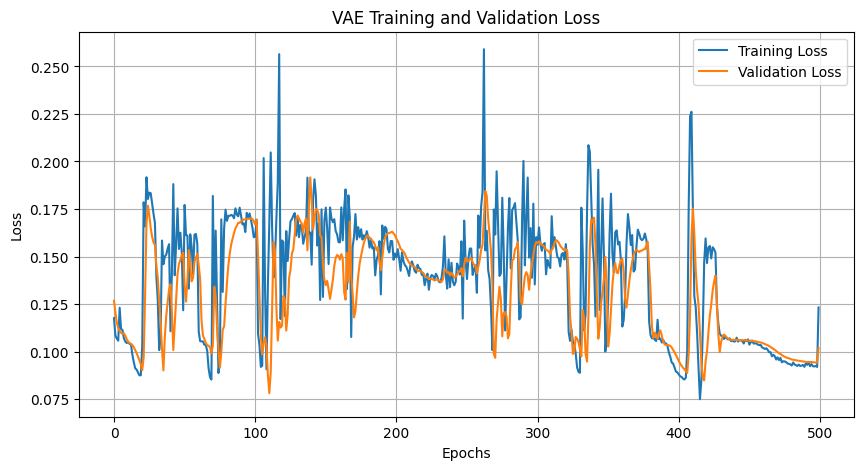

VAE Training time: 00:15:50


In [23]:
num_res_blocks = [NUM_RES_BLOCKS] * NUM_LAYERS
num_channels = [NUM_CHANNELS_START << i for i in range(NUM_LAYERS)]

# Change the format to put channels last to better utilize Blackwell
model = AutoencoderModel(
    sigmoid_expansion=SIGMOID_EXPANSION,
    spatial_dims=3,
    in_channels=1,
    out_channels=1,
    num_res_blocks=num_res_blocks,
    num_channels=num_channels,
    attention_levels=[False, False, False],
    latent_channels=LATENT_CHANNELS,
    norm_num_groups=NUM_NORM_GROUPS,
    norm_eps=1e-6,
    with_encoder_nonlocal_attn=False,
    with_decoder_nonlocal_attn=False,
    include_fc=False,
    use_combined_linear=False,
    use_flash_attention=False,
    use_checkpointing=False,
    use_convtranspose=False,
    num_splits=1,
    dim_split=0,
    norm_float16=False,
    print_info=False,
    save_mem=False,
).to(DEVICE, memory_format=torch.channels_last_3d)

# Make the init less aggressive
model.apply(lambda m: normal_init(m, std=INIT_STD))

optimizer = torch.optim.AdamW(
    model.parameters(),
    weight_decay=WEIGHT_DECAY,
    eps=1e-4,
)

with Timer("VAE Training"):
    model, _ = train(model, optimizer, train_loader, val_loader, logging=True)

Training from scratch was largely futile, but some of the tactics learned here can be utilized for transfer learning later.